In [4]:
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, fixed
from ipywidgets import IntSlider, FloatSlider

def locate_pcr_tubes(image_path, min_area=100, circularity_threshold=0.2):
    # Read the image
    img = cv2.imread(image_path)
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Apply threshold to create a binary image
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter contours based on area and circularity
    pcr_tubes = []
    
    for contour in contours:
        area = cv2.contourArea(contour)
        perimeter = max(cv2.arcLength(contour, True), 0.01)
        circularity = 4 * np.pi * area / (perimeter * perimeter)
        
        if area > min_area and circularity > circularity_threshold:
            (x, y), radius = cv2.minEnclosingCircle(contour)
            center = (int(x), int(y))
            radius = int(radius)
            pcr_tubes.append({"x": center[0], "y": center[1], "radius": radius})
    
    # Draw circles around detected PCR tubes
    img_with_tubes = img.copy()
    for tube in pcr_tubes:
        cv2.circle(img_with_tubes, (tube['x'], tube['y']), tube['radius'], (0, 255, 0), 2)
    
    return img_with_tubes, len(pcr_tubes)

def display_tubes(image_path, min_area, circularity_threshold):
    img_with_tubes, num_tubes = locate_pcr_tubes(image_path, min_area, circularity_threshold)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img_with_tubes, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected PCR Tubes: {num_tubes}")
    plt.axis('off')
    plt.show()

In [5]:
# Usage
# image_path = '200/img/IMG00000000000001975671.png'
image_path = '110/img/IMG00000000000001835460.png'
# Create interactive widgets
interact(
    display_tubes,
    image_path=fixed(image_path),
    min_area=IntSlider(min=10, max=500, step=10, value=100, description='Min Area:'),
    circularity_threshold=FloatSlider(min=0.1, max=1.0, step=0.05, value=0.2, description='Circularity:')
)

interactive(children=(IntSlider(value=100, description='Min Area:', max=500, min=10, step=10), FloatSlider(val…

<function __main__.display_tubes(image_path, min_area, circularity_threshold)>

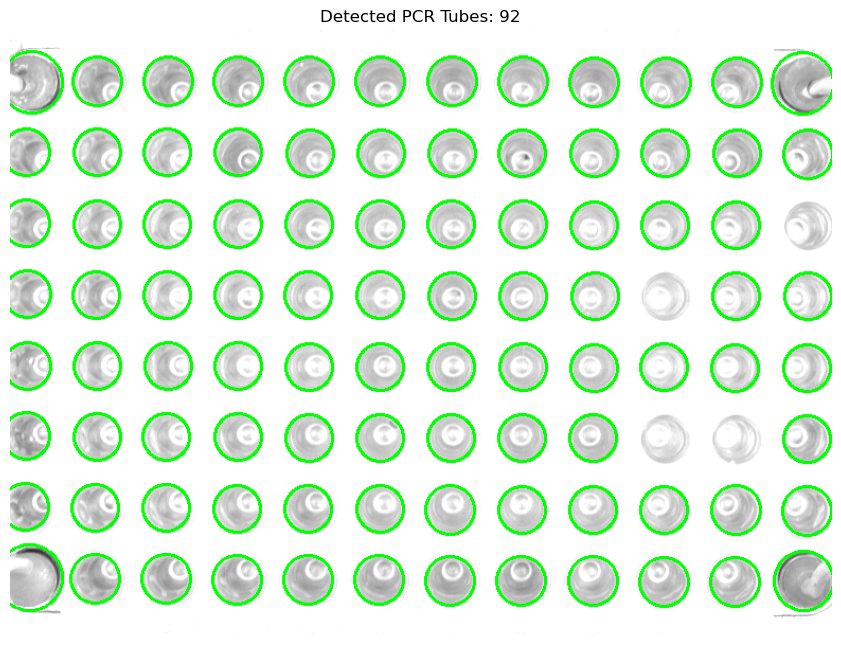

In [2]:
image_path = '110/img/IMG00000000000001835460.png'
display_tubes(image_path=image_path, min_area=100, circularity_threshold=0.2)

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, fixed
from ipywidgets import IntSlider, FloatSlider
from scipy.spatial import distance
from scipy.cluster import hierarchy

def locate_pcr_tubes(image_path, min_area=100, circularity_threshold=0.2):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    pcr_tubes = []
    for contour in contours:
        area = cv2.contourArea(contour)
        perimeter = max(cv2.arcLength(contour, True), 0.1)
        circularity = 4 * np.pi * area / (perimeter * perimeter)
        
        if area > min_area and circularity > circularity_threshold:
            (x, y), radius = cv2.minEnclosingCircle(contour)
            center = (int(x), int(y))
            radius = int(radius)
            pcr_tubes.append({"x": center[0], "y": center[1], "radius": radius})
    
    return pcr_tubes, img

from sklearn.cluster import DBSCAN

def infer_missing_tubes(pcr_tubes, img_shape):
    if not pcr_tubes:
        return []

    # Extract coordinates
    coords = np.array([[tube['x'], tube['y']] for tube in pcr_tubes])

    # Use DBSCAN for clustering
    dbscan_x = DBSCAN(eps=50, min_samples=2).fit(coords[:, 0].reshape(-1, 1))
    dbscan_y = DBSCAN(eps=50, min_samples=2).fit(coords[:, 1].reshape(-1, 1))

    # Get unique columns and rows
    unique_cols = np.sort(np.unique(dbscan_x.labels_))
    unique_rows = np.sort(np.unique(dbscan_y.labels_))

    # Create a grid
    grid = np.zeros((len(unique_rows), len(unique_cols)), dtype=bool)

    # Mark detected tubes in the grid
    for tube in pcr_tubes:
        row = np.argmin(np.abs(unique_rows - dbscan_y.fit_predict([[tube['y']]])[0]))
        col = np.argmin(np.abs(unique_cols - dbscan_x.fit_predict([[tube['x']]])[0]))
        grid[row, col] = True

    # Infer missing tubes
    inferred_tubes = []
    avg_radius = np.mean([tube['radius'] for tube in pcr_tubes])

    for i in range(len(unique_rows)):
        for j in range(len(unique_cols)):
            if not grid[i, j]:
                # Check if surrounded by detected tubes
                if (i > 0 and i < len(unique_rows) - 1 and 
                    j > 0 and j < len(unique_cols) - 1 and
                    grid[i-1, j] and grid[i+1, j] and grid[i, j-1] and grid[i, j+1]):
                    x = np.mean(coords[dbscan_x.labels_ == unique_cols[j]][:, 0])
                    y = np.mean(coords[dbscan_y.labels_ == unique_rows[i]][:, 1])
                    inferred_tubes.append({
                        "x": int(x),
                        "y": int(y),
                        "radius": int(avg_radius),
                        "inferred": True
                    })
    print(grid)
    return pcr_tubes + inferred_tubes

def display_tubes(image_path, min_area, circularity_threshold):
    pcr_tubes, img = locate_pcr_tubes(image_path, min_area, circularity_threshold)
    all_tubes = infer_missing_tubes(pcr_tubes, img.shape)
    
    img_with_tubes = img.copy()
    for tube in all_tubes:
        color = (0, 255, 0) if 'inferred' not in tube else (0, 0, 255)  # Green for detected, Red for inferred
        cv2.circle(img_with_tubes, (tube['x'], tube['y']), tube['radius'], color, 2)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img_with_tubes, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected PCR Tubes: {len(pcr_tubes)}, Inferred: {len(all_tubes) - len(pcr_tubes)}")
    plt.axis('off')
    plt.show()

# Assuming your image is named 'pcr_plate.jpg' and is in the same directory as this notebook
# image_path = 'pcr_plate.jpg'

# Create interactive widgets
interact(
    display_tubes,
    image_path=fixed(image_path),
    min_area=IntSlider(min=10, max=500, step=10, value=100, description='Min Area:'),
    circularity_threshold=FloatSlider(min=0.1, max=1.0, step=0.05, value=0.2, description='Circularity:')
)

interactive(children=(IntSlider(value=100, description='Min Area:', max=500, min=10, step=10), FloatSlider(val…

<function __main__.display_tubes(image_path, min_area, circularity_threshold)>

In [10]:
image_path = '110/img/IMG00000000000001835460.png'
pcr_tubes, img = locate_pcr_tubes(image_path=image_path, min_area=100, circularity_threshold=0.2)

In [12]:
# Extract coordinates
coords = np.array([[tube['x'], tube['y']] for tube in pcr_tubes])

# Use DBSCAN for clustering
dbscan_x = DBSCAN(eps=50, min_samples=2).fit(coords[:, 0].reshape(-1, 1))
dbscan_y = DBSCAN(eps=50, min_samples=2).fit(coords[:, 1].reshape(-1, 1))

In [18]:
unique_cols = np.sort(np.unique(dbscan_x.labels_))
unique_rows = np.sort(np.unique(dbscan_y.labels_))

In [21]:
grid = np.zeros((len(unique_rows), len(unique_cols)), dtype=bool)

In [22]:
grid.size

96

In [29]:
dbscan_y.fit_predict([[pcr_tubes[3]['y']]])

array([-1])

In [33]:
dbscan_x = DBSCAN(eps=50, min_samples=2).fit(coords[:, 0].reshape(-1, 1))
dbscan_y = DBSCAN(eps=50, min_samples=2).fit(coords[:, 1].reshape(-1, 1))

In [48]:
dbscan_x.fit_predict(coords[:, 0].reshape(-1, 1))

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 10,  0,  1,  2,  3,
        4,  5,  6,  7,  8,  9, 11, 10,  2,  3,  4,  5,  6,  7,  8,  9, 11,
       10,  0,  2,  1,  3,  4,  5,  6,  7,  8,  9, 11, 10,  0,  2,  3,  4,
        5,  6,  7,  8,  9, 11,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11,
       10,  0,  1,  2,  3,  4,  5,  6,  8, 11,  7,  9,  0,  1,  2,  3,  4,
        5,  6,  7,  8,  9, 10, 11])

In [49]:
import numpy as np
import scipy as sp

def dbscan_predict(dbscan_model, X_new, metric=sp.spatial.distance.cosine):
    # Result is noise by default
    y_new = np.ones(shape=len(X_new), dtype=int)*-1 

    # Iterate all input samples for a label
    for j, x_new in enumerate(X_new):
        # Find a core sample closer than EPS
        for i, x_core in enumerate(dbscan_model.components_): 
            if metric(x_new, x_core) < dbscan_model.eps:
                # Assign label of x_core to x_new
                y_new[j] = dbscan_model.labels_[dbscan_model.core_sample_indices_[i]]
                break

    return y_new

In [53]:
dbscan_predict(dbscan_x, [[684]])

array([0])

In [51]:
coords

array([[684, 521],
       [617, 521],
       [550, 520],
       [482, 520],
       [415, 520],
       [348, 519],
       [281, 519],
       [214, 519],
       [147, 518],
       [ 80, 518],
       [749, 520],
       [ 18, 517],
       [752, 454],
       [685, 453],
       [617, 453],
       [550, 453],
       [483, 453],
       [415, 453],
       [349, 452],
       [281, 452],
       [214, 452],
       [147, 451],
       [ 80, 451],
       [ 14, 450],
       [752, 386],
       [550, 385],
       [483, 385],
       [416, 385],
       [349, 385],
       [282, 385],
       [215, 384],
       [147, 384],
       [ 82, 384],
       [ 15, 383],
       [752, 319],
       [684, 319],
       [551, 319],
       [617, 318],
       [484, 318],
       [416, 318],
       [349, 318],
       [282, 318],
       [215, 317],
       [149, 317],
       [ 82, 317],
       [ 16, 317],
       [753, 251],
       [685, 251],
       [552, 251],
       [484, 251],
       [417, 251],
       [349, 250],
       [281,

In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, fixed
from ipywidgets import IntSlider, FloatSlider, Text
from sklearn.cluster import KMeans

def locate_pcr_tubes(image_path, min_area=100, circularity_threshold=0.2):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    pcr_tubes = []
    for contour in contours:
        area = cv2.contourArea(contour)
        perimeter = max(cv2.arcLength(contour, True), 0.1)
        circularity = 4 * np.pi * area / (perimeter * perimeter)
        
        if area > min_area and circularity > circularity_threshold:
            (x, y), radius = cv2.minEnclosingCircle(contour)
            center = (int(x), int(y))
            radius = int(radius)
            pcr_tubes.append({"x": center[0], "y": center[1], "radius": radius})
    
    return pcr_tubes, img

def infer_missing_tubes(pcr_tubes, img_shape):
    if not pcr_tubes:
        return []

    # Extract coordinates
    coords = np.array([[tube['x'], tube['y']] for tube in pcr_tubes])

    # Estimate number of rows and columns
    # n_rows = int(np.sqrt(len(pcr_tubes)))
    n_rows = 8
    # n_cols = int(np.ceil(len(pcr_tubes) / n_rows))
    n_cols = 12

    # Use KMeans for clustering
    kmeans_x = KMeans(n_clusters=n_cols, random_state=0).fit(coords[:, 0].reshape(-1, 1))
    kmeans_y = KMeans(n_clusters=n_rows, random_state=0).fit(coords[:, 1].reshape(-1, 1))

    # Get sorted cluster centers as unique columns and rows
    unique_cols = np.sort(kmeans_x.cluster_centers_.flatten())
    unique_rows = np.sort(kmeans_y.cluster_centers_.flatten())

    # Create a grid
    grid = np.zeros((len(unique_rows), len(unique_cols)), dtype=bool)

    # Mark detected tubes in the grid
    for tube in pcr_tubes:
        row = np.argmin(np.abs(unique_rows - tube['y']))
        col = np.argmin(np.abs(unique_cols - tube['x']))
        grid[row, col] = True

    # Infer missing tubes
    inferred_tubes = []
    avg_radius = np.mean([tube['radius'] for tube in pcr_tubes])

    for i in range(len(unique_rows)):
        for j in range(len(unique_cols)):
            if not grid[i, j]:
                print(1)
                # # Check if surrounded by detected tubes
                # if (i > 0 and i < len(unique_rows) - 1 and 
                #     j > 0 and j < len(unique_cols) - 1 and
                #     grid[i-1, j] and grid[i+1, j] and grid[i, j-1] and grid[i, j+1]):
                if True:
                    inferred_tubes.append({
                        "x": int(unique_cols[j]),
                        "y": int(unique_rows[i]),
                        "radius": int(avg_radius),
                        "inferred": True
                    })
    print(inferred_tubes)
    return pcr_tubes + inferred_tubes

def display_tubes(image_path, min_area, circularity_threshold):
    pcr_tubes, img = locate_pcr_tubes(image_path, min_area, circularity_threshold)
    all_tubes = infer_missing_tubes(pcr_tubes, img.shape)
    
    img_with_tubes = img.copy()
    for tube in all_tubes:
        color = (0, 255, 0) if 'inferred' not in tube else (0, 0, 255)  # Green for detected, Red for inferred
        cv2.circle(img_with_tubes, (tube['x'], tube['y']), tube['radius'], color, 2)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img_with_tubes, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected PCR Tubes: {len(pcr_tubes)}, Inferred: {len(all_tubes) - len(pcr_tubes)}")
    plt.axis('off')
    plt.show()

# Assuming your image is named 'pcr_plate.jpg' and is in the same directory as this notebook
image_path = '200/img/IMG00000000000001975884.png'

# Create interactive widgets
interact(
    display_tubes,
    image_path=Text(image_path),
    min_area=IntSlider(min=10, max=500, step=10, value=100, description='Min Area:'),
    circularity_threshold=FloatSlider(min=0.1, max=1.0, step=0.05, value=0.2, description='Circularity:')
)

interactive(children=(Text(value='200/img/IMG00000000000001975884.png', description='image_path'), IntSlider(v…

<function __main__.display_tubes(image_path, min_area, circularity_threshold)>

In [77]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, fixed
from ipywidgets import IntSlider, FloatSlider, Text
from sklearn.cluster import KMeans
from scipy.spatial import distance

def locate_pcr_tubes(image_path, min_area=100, circularity_threshold=0.2):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    pcr_tubes = []
    for contour in contours:
        area = cv2.contourArea(contour)
        perimeter = max(cv2.arcLength(contour, True), 0.1)
        circularity = 4 * np.pi * area / (perimeter * perimeter)
        
        if area > min_area and circularity > circularity_threshold:
            (x, y), radius = cv2.minEnclosingCircle(contour)
            center = (int(x), int(y))
            radius = int(radius)
            pcr_tubes.append({"x": center[0], "y": center[1], "radius": radius})
    
    return pcr_tubes, img

def infer_missing_tubes(pcr_tubes, img_shape):
    if not pcr_tubes:
        return []

    # Extract coordinates
    coords = np.array([[tube['x'], tube['y']] for tube in pcr_tubes])

    # Perform KMeans clustering separately for x and y coordinates
    n_cols, n_rows = 12, 8  # Assuming 8x12 grid
    kmeans_x = KMeans(n_clusters=n_cols, random_state=0, n_init=10).fit(coords[:, 0].reshape(-1, 1))
    kmeans_y = KMeans(n_clusters=n_rows, random_state=0, n_init=10).fit(coords[:, 1].reshape(-1, 1))

    # Sort cluster centers to get grid lines
    x_lines = np.sort(kmeans_x.cluster_centers_.flatten())
    y_lines = np.sort(kmeans_y.cluster_centers_.flatten())

    # Calculate average radius
    avg_radius = np.mean([tube['radius'] for tube in pcr_tubes])

    # Create a dictionary to store detected tubes
    detected_tubes = {(tube['x'], tube['y']): tube for tube in pcr_tubes}

    # Infer missing tubes
    all_tubes = []
    for y in y_lines:
        for x in x_lines:
            closest_point = (int(x), int(y))
            if closest_point in detected_tubes:
                all_tubes.append(detected_tubes[closest_point])
            else:
                all_tubes.append({
                    "x": int(x),
                    "y": int(y),
                    "radius": int(avg_radius),
                    "inferred": True
                })

    return all_tubes

def display_tubes(image_path, min_area, circularity_threshold):
    pcr_tubes, img = locate_pcr_tubes(image_path, min_area, circularity_threshold)
    # all_tubes = infer_missing_tubes(pcr_tubes, img.shape)
    all_tubes = pcr_tubes
    
    img_with_tubes = img.copy()
    for tube in all_tubes:
        color = (0, 255, 0) if 'inferred' not in tube else (0, 0, 255)  # Green for detected, Red for inferred
        cv2.circle(img_with_tubes, (tube['x'], tube['y']), tube['radius'], color, 2)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img_with_tubes, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected PCR Tubes: {len(pcr_tubes)}, Inferred: {len(all_tubes) - len(pcr_tubes)}")
    plt.axis('off')
    plt.show()

# Assuming your image is named 'pcr_plate.jpg' and is in the same directory as this notebook
# image_path = '200/img/IMG00000000000001975884.png'
# image_path= "110/img/IMG00000000000001836289.png"
image_path = 'rotated_image.jpg'

# Create interactive widgets
interact(
    display_tubes,
    image_path=Text(image_path),
    min_area=IntSlider(min=10, max=500, step=10, value=100, description='Min Area:'),
    circularity_threshold=FloatSlider(min=0.1, max=1.0, step=0.05, value=0.2, description='Circularity:')
)

interactive(children=(Text(value='rotated_image.jpg', description='image_path'), IntSlider(value=100, descript…

<function __main__.display_tubes(image_path, min_area, circularity_threshold)>

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, fixed
from ipywidgets import IntSlider, FloatSlider, Text, TypedTuple
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def locate_pcr_tubes(image_path, min_area=100, circularity_threshold=0.2):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    pcr_tubes = []
    for contour in contours:
        area = cv2.contourArea(contour)
        perimeter = max(cv2.arcLength(contour, True), 0.1)
        circularity = 4 * np.pi * area / (perimeter * perimeter)
        
        if area > min_area and circularity > circularity_threshold:
            (x, y), radius = cv2.minEnclosingCircle(contour)
            center = (int(x), int(y))
            radius = int(radius)
            pcr_tubes.append({"x": center[0], "y": center[1], "radius": radius})
    
    return pcr_tubes, img


def calculate_rotation_angle(coords):
    # Perform PCA
    pca = PCA(n_components=2)
    pca.fit(coords)

    # Get the angle of the first principal component
    angle = np.arctan2(pca.components_[0, 1], pca.components_[0, 0])
    
    # Convert to degrees
    angle_degrees = np.degrees(angle)
    
    # Adjust angle to be between -45 and 45 degrees
    if angle_degrees > 45:
        angle_degrees -= 90
    elif angle_degrees < -45:
        angle_degrees += 90
    
    return angle_degrees

def rotate_point(origin, point, angle):
    """
    Rotate a point counterclockwise by a given angle around a given origin.
    """
    ox, oy = origin
    px, py = point

    qx = ox + np.cos(angle) * (px - ox) - np.sin(angle) * (py - oy)
    qy = oy + np.sin(angle) * (px - ox) + np.cos(angle) * (py - oy)
    return qx, qy

def infer_missing_tubes(pcr_tubes, image_shape, tubes_size=(8, 12), rotate='auto'):
    if not pcr_tubes:
        return []

    # Extract coordinates
    coords = np.array([[tube['x'], tube['y']] for tube in pcr_tubes])

    # Calculate rotation angle
    if rotate == 'auto':
        angle = calculate_rotation_angle(coords)
    else:
        angle = float(rotate)
    print(f"Calculated rotation angle: {angle:.2f} degrees")

    # Rotate coordinates
    center = tuple(np.mean(coords, axis=0))
    rotated_coords = np.array([rotate_point(center, (x, y), np.radians(-angle)) for x, y in coords])

    # Perform KMeans clustering separately for x and y coordinates of rotated points
    print(tubes_size)
    n_rows, n_cols = tubes_size  # Assuming 8x12 grid
    kmeans_x = KMeans(n_clusters=n_cols, random_state=0, n_init=10).fit(rotated_coords[:, 0].reshape(-1, 1))
    kmeans_y = KMeans(n_clusters=n_rows, random_state=0, n_init=10).fit(rotated_coords[:, 1].reshape(-1, 1))

    # Sort cluster centers to get grid lines
    x_lines = np.sort(kmeans_x.cluster_centers_.flatten())
    y_lines = np.sort(kmeans_y.cluster_centers_.flatten())

    # Calculate average radius
    avg_radius = np.mean([tube['radius'] for tube in pcr_tubes])

    # Create a dictionary to store detected tubes
    detected_tubes = {(tube['x'], tube['y']): tube for tube in pcr_tubes}

    # Infer missing tubes
    all_tubes = []
    for y in y_lines:
        for x in x_lines:
            # Rotate the point back to the original orientation
            original_x, original_y = rotate_point(center, (x, y), np.radians(angle))
            closest_point = (int(original_x), int(original_y))
            if closest_point in detected_tubes:
                all_tubes.append(detected_tubes[closest_point])
            else:
                all_tubes.append({
                    "x": int(original_x),
                    "y": int(original_y),
                    "radius": int(avg_radius),
                    "inferred": True
                })

    return all_tubes

def display_tubes(image_path, min_area, circularity_threshold, tubes_shape, rotate):
    pcr_tubes, img = locate_pcr_tubes(image_path, min_area, circularity_threshold)
    all_tubes = infer_missing_tubes(pcr_tubes, img.shape, tubes_shape, rotate)
    print(all_tubes)
    img_with_tubes = img.copy()
    for tube in all_tubes:
        color = (0, 255, 0) if 'inferred' not in tube else (0, 0, 255)  # Green for detected, Red for inferred
        cv2.circle(img_with_tubes, (tube['x'], tube['y']), tube['radius'], color, 2)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img_with_tubes, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected PCR Tubes: {len(pcr_tubes)}, Inferred: {len(all_tubes) - len(pcr_tubes)}")
    plt.axis('off')
    plt.show()

# Assuming your image is named 'pcr_plate.jpg' and is in the same directory as this notebook
image_path = '200/img/IMG00000000000001975884.png'
# image_path = 'rotated_image.jpg'
rotate = 'auto'

# Create interactive widgets
interact(
    display_tubes,
    image_path=Text(image_path),
    min_area=IntSlider(min=10, max=500, step=10, value=100, description='Min Area:'),
    circularity_threshold=FloatSlider(min=0.1, max=1.0, step=0.05, value=0.2, description='Circularity:'),
    tubes_shape= fixed((8, 12)),
    rotate = Text(rotate),
)

interactive(children=(Text(value='200/img/IMG00000000000001975884.png', description='image_path'), IntSlider(v…

<function __main__.display_tubes(image_path, min_area, circularity_threshold, tubes_shape, rotate)>

In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, fixed, IntSlider, FloatSlider, Text
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, fixed
from ipywidgets import IntSlider, FloatSlider, Text
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def locate_pcr_tubes(image_path, min_area=100, circularity_threshold=0.2):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    pcr_tubes = []
    for contour in contours:
        area = cv2.contourArea(contour)
        perimeter = max(cv2.arcLength(contour, True), 0.1)
        circularity = 4 * np.pi * area / (perimeter * perimeter)
        
        if area > min_area and circularity > circularity_threshold:
            (x, y), radius = cv2.minEnclosingCircle(contour)
            center = (int(x), int(y))
            radius = int(radius)
            pcr_tubes.append({"x": center[0], "y": center[1], "radius": radius})
    
    return pcr_tubes, img


def calculate_rotation_angle(coords):
    # Perform PCA
    pca = PCA(n_components=2)
    pca.fit(coords)

    # Get the angle of the first principal component
    angle = np.arctan2(pca.components_[0, 1], pca.components_[0, 0])
    
    # Convert to degrees
    angle_degrees = np.degrees(angle)
    
    # Adjust angle to be between -45 and 45 degrees
    if angle_degrees > 45:
        angle_degrees -= 90
    elif angle_degrees < -45:
        angle_degrees += 90
    
    return angle_degrees


def rotate_point(origin, point, angle):
    """
    Rotate a point counterclockwise by a given angle around a given origin.
    """
    ox, oy = origin
    px, py = point

    qx = ox + np.cos(angle) * (px - ox) - np.sin(angle) * (py - oy)
    qy = oy + np.sin(angle) * (px - ox) + np.cos(angle) * (py - oy)
    return qx, qy


def infer_missing_tubes(pcr_tubes, image_shape, tubes_size=(8, 12), rotate='auto'):
    if not pcr_tubes:
        return []

    # Extract coordinates
    coords = np.array([[tube['x'], tube['y']] for tube in pcr_tubes])

    # Calculate rotation angle
    if rotate == 'auto':
        angle = calculate_rotation_angle(coords)
    else:
        angle = float(rotate)
    print(f"Calculated rotation angle: {angle:.2f} degrees")

    # Rotate coordinates
    center = tuple(np.mean(coords, axis=0))
    rotated_coords = np.array([rotate_point(center, (x, y), np.radians(-angle)) for x, y in coords])

    # Perform KMeans clustering separately for x and y coordinates of rotated points
    print(tubes_size)
    n_rows, n_cols = tubes_size  # Assuming 8x12 grid
    kmeans_x = KMeans(n_clusters=n_cols, random_state=0, n_init=10).fit(rotated_coords[:, 0].reshape(-1, 1))
    kmeans_y = KMeans(n_clusters=n_rows, random_state=0, n_init=10).fit(rotated_coords[:, 1].reshape(-1, 1))

    # Sort cluster centers to get grid lines
    x_lines = np.sort(kmeans_x.cluster_centers_.flatten())
    y_lines = np.sort(kmeans_y.cluster_centers_.flatten())

    # Calculate average radius
    avg_radius = np.mean([tube['radius'] for tube in pcr_tubes])

    # Create a dictionary to store detected tubes
    detected_tubes = {(tube['x'], tube['y']): tube for tube in pcr_tubes}

    # Infer missing tubes
    all_tubes = []
    for y in y_lines:
        for x in x_lines:
            # Rotate the point back to the original orientation
            original_x, original_y = rotate_point(center, (x, y), np.radians(angle))
            closest_point = (int(original_x), int(original_y))
            if closest_point in detected_tubes:
                all_tubes.append(detected_tubes[closest_point])
            else:
                all_tubes.append({
                    "x": int(original_x),
                    "y": int(original_y),
                    "radius": int(avg_radius),
                    "inferred": True
                })

    return all_tubes


def detect_inner_circles(image, tubes, roi_size=30):
    
    def create_circular_mask(h, w, center, radius):
        Y, X = np.ogrid[:h, :w]
        dist_from_center = np.sqrt((X - center[0])**2 + (Y-center[1])**2)
        mask = dist_from_center <= radius
        return mask

    def find_brightest_point(roi, mask):
        # Apply mask to ROI
        masked_roi = cv2.bitwise_and(roi, roi, mask=mask.astype(np.uint8))
        
        # Apply 5x5 average filter
        kernel = np.ones((5,5), np.float32) / 25
        avg_roi = cv2.filter2D(masked_roi, -1, kernel)
        
        # Find the coordinates of the maximum average intensity pixel
        y, x = np.unravel_index(np.argmax(avg_roi), avg_roi.shape)
        return x, y
    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    inner_circles = []

    for tube in tubes:
        x, y, r = tube['x'], tube['y'], tube['radius']
        
        # Define ROI
        roi_x = max(0, x - roi_size // 2)
        roi_y = max(0, y - roi_size // 2)
        roi = gray[roi_y:roi_y+roi_size, roi_x:roi_x+roi_size]
        
        # Create circular mask
        mask = create_circular_mask(roi_size, roi_size, (roi_size//2, roi_size//2), r)
        
        # Detect circles in ROI
        circles = cv2.HoughCircles(
            roi, 
            cv2.HOUGH_GRADIENT, 
            dp=1, 
            minDist=roi_size//2,
            param1=50, 
            param2=15, 
            minRadius=5, 
            maxRadius=r-2
        )
        
        # if circles is not None:
        #     circles = np.round(circles[0, :]).astype("int")
        #     # Get the circle with maximum radius (assuming it's the most prominent inner circle)
        #     max_circle = max(circles, key=lambda c: c[2])
        #     cx, cy, cr = max_circle
        #     inner_circles.append({
        #         'x': roi_x + cx,
        #         'y': roi_y + cy,
        #         'radius': cr,
        #         'method': 'hough'
        #     })
        # else:
        #     # Find the brightest point within the circular mask using 5x5 average kernel
        #     cx, cy = find_brightest_point(roi, mask)
        #     inner_circles.append({
        #         'x': roi_x + cx,
        #         'y': roi_y + cy,
        #         'radius': 3,  # Set a small default radius for visualization
        #         'method': 'avg_brightness'
        #     })
        
        cx, cy = find_brightest_point(roi, mask)
        inner_circles.append({
            'x': roi_x + cx,
            'y': roi_y + cy,
            'radius': 3,  # Set a small default radius for visualization
            'method': 'avg_brightness'
        })


    return inner_circles


def display_tubes(image_path, min_area, circularity_threshold, tubes_shape, rotate):
    min_area, circularity_threshold = min_area, circularity_threshold
    # center_x, center_y = rotation_center
    
    pcr_tubes, img = locate_pcr_tubes(image_path, min_area, circularity_threshold)
    all_tubes = infer_missing_tubes(pcr_tubes, img.shape)
    inner_circles = detect_inner_circles(img, all_tubes)
    
    # for _ in inner_circles:
    #     print(_)
    
    img_with_tubes = img.copy()
    for tube, inner_circle in zip(all_tubes, inner_circles):
        color = (0, 255, 0) if 'inferred' not in tube else (0, 0, 255)  # Green for detected, Red for inferred
        cv2.circle(img_with_tubes, (tube['x'], tube['y']), tube['radius'], color, 2)
        
        if inner_circle:
            cv2.circle(img_with_tubes, (inner_circle['x'], inner_circle['y']), inner_circle['radius'], (0, 0, 0), 1)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img_with_tubes, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected PCR Tubes: {len(pcr_tubes)}, Inferred: {len(all_tubes) - len(pcr_tubes)}")
    plt.axis('off')
    plt.show()

# Assuming your image is named 'pcr_plate.jpg' and is in the same directory as this notebook
image_path = '200/img/IMG00000000000001975884.png'
# image_path = 'rotated_image.jpg'
rotate = 'auto'

# Create interactive widgets
interact(
    display_tubes,
    image_path=Text(image_path),
    min_area=IntSlider(min=10, max=500, step=10, value=100, description='Min Area:'),
    circularity_threshold=FloatSlider(min=0.1, max=1.0, step=0.05, value=0.2, description='Circularity:'),
    tubes_shape= fixed((8, 12)),
    rotate = Text(rotate),
)

interactive(children=(Text(value='200/img/IMG00000000000001975884.png', description='image_path'), IntSlider(v…

<function __main__.display_tubes(image_path, min_area, circularity_threshold, tubes_shape, rotate)>